# MVP — Machine Learning & Analytics

**Nome:** Marcela P. De Oliveira da Silva<br>
**Matrícula:** 4052026000575<br>
**Data:** 05/07/2026<br>
**Dataset:** Banknote Authentication Dataset — UCI Machine Learning Repository — https://archive.ics.uci.edu/dataset/267/banknote+authentication<br>
**Tipo de problema:** Classificação

---

## Observações importantes

Este notebook é um **template** para o desenvolvimento do MVP da Sprint de Machine Learning & Analytics. Ele não deve ser preenchido de forma mecânica: adapte as seções ao problema escolhido e remova partes que não fizerem sentido.

O objetivo do MVP é demonstrar um fluxo completo e bem documentado de Machine Learning: definição do problema, entendimento dos dados, preparação, modelagem, avaliação e discussão crítica dos resultados.

> **Atenção:** profundidade e clareza valem mais do que quantidade de técnicas. É melhor apresentar uma solução simples, bem justificada e executável do que testar muitos modelos sem análise.

> **Atenção 2:** o dataset utilizado neste template é apenas um exemplo sintético para que o notebook execute sem erros. Substitua pela base escolhida, carregada por URL pública ou fonte diretamente acessível no Colab.


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema
Este MVP tem como objetivo resolver um problema de classificação binária relacionado à autenticação de cédulas bancárias. A partir de atributos numéricos extraídos de imagens digitalizadas de cédulas, o modelo deve prever se uma cédula é autêntica ou falsa.

Esse problema é relevante porque processos de autenticação automática podem apoiar instituições financeiras, sistemas de triagem e mecanismos de prevenção a fraudes. O usuário interessado nessa solução seria uma organização que precisa classificar rapidamente cédulas com base em características extraídas das imagens.

O problema pode ser tratado como Machine Learning porque existe um conjunto de dados rotulado, no qual cada cédula possui atributos de entrada e uma classe conhecida. Assim, é possível treinar modelos supervisionados para aprender padrões associados a cédulas autênticas e falsas.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir, comparar e avaliar modelos de Machine Learning capazes de classificar cédulas bancárias como autênticas ou falsas a partir de atributos numéricos extraídos de imagens.

Para isso, será comparado um modelo baseline com diferentes modelos candidatos, avaliando métricas adequadas para classificação e discutindo limitações, erros e possíveis melhorias.

## 1.3 Tipo de problema

Tipo escolhido: Classificação.

Justificativa: O problema é de classificação porque o objetivo é prever uma classe/categoria para cada registro. Neste caso, a variável-alvo indica se a cédula é autêntica ou falsa. Como existem apenas duas classes possíveis, trata-se de uma classificação binária.

## 1.4 Premissas, hipóteses e critérios de sucesso

Hipóteses iniciais:
1. As características numéricas extraídas das imagens possuem informação suficiente para diferenciar cédulas autênticas e falsas.
2. Modelos de classificação supervisionada devem apresentar desempenho superior ao baseline.
3. Modelos não lineares podem capturar melhor os padrões dos dados do que modelos lineares simples.

Critérios de sucesso:
1. O modelo final deve superar o baseline nas principais métricas de classificação.
2. A métrica principal será o F1-score, pois ela considera simultaneamente precisão e recall.
3. A matriz de confusão será analisada para entender os principais tipos de erro.
4. O notebook deve executar do início ao fim sem erros, com código limpo, documentação e resultados interpretáveis.

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [16]:
# === Setup básico e reprodutibilidade ===

import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Instale bibliotecas extras apenas se forem realmente necessárias.

> **Comentário:** quanto mais dependências externas, maior a chance de o notebook não executar no momento da correção. Mantenha o projeto enxuto.


In [17]:
# Não foram necessárias dependências adicionais.
# O MVP utiliza bibliotecas já disponíveis no ambiente padrão do Google Colab.


## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [18]:
def evaluate_classification(y_true, y_pred, proba=None):
    """
    Calcula métricas principais para problema de classificação binária.
    """
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred)
    }

    if proba is not None:
        try:
            results["roc_auc"] = roc_auc_score(y_true, proba)
        except Exception:
            results["roc_auc"] = np.nan

    return results


def show_results_table(results_dict):
    """
    Exibe os resultados dos modelos em formato de tabela ordenada pelo F1-score.
    """
    results_df = pd.DataFrame(results_dict).T
    return results_df.sort_values(by="f1_score", ascending=False)

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset escolhido foi o **Banknote Authentication Dataset**, disponibilizado no UCI Machine Learning Repository.

A base contém atributos numéricos extraídos de imagens digitalizadas de cédulas bancárias. Esses atributos foram obtidos a partir de transformações aplicadas às imagens e são utilizados para diferenciar cédulas autênticas de cédulas falsas.

A base foi escolhida porque é pública, possui estrutura tabular, não exige login ou token para acesso e é adequada para um problema supervisionado de classificação binária. Além disso, o tamanho da base permite treinar e comparar modelos no Google Colab sem alto custo computacional.

Fonte dos dados: https://archive.ics.uci.edu/dataset/267/banknote+authentication


## 3.2 Carga dos dados

Substitua o exemplo abaixo pelo carregamento real do seu dataset.

> **Comentário:** caso use Kaggle ou outra fonte que exija autenticação, prefira disponibilizar uma versão pública alternativa ou explicar claramente como o professor conseguirá executar o notebook sem configuração adicional.


In [19]:
# === Carga dos dados ===

url = "https://raw.githubusercontent.com/MarcelaPhos/mvp-ml-banknote-authentication/refs/heads/main/data_banknote_authentication.txt"

columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

df = pd.read_csv(url, header=None, names=columns)

df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## 3.3 Visão geral do dataset

Antes de modelar, apresente uma visão geral da base.

**O que incluir:**
- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.


In [20]:
print("Formato do dataset:", df.shape)

print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))

print("\nDuplicatas:", df.duplicated().sum())

print("\nEstatísticas descritivas:")
display(df.describe().T)

print("\nAmostra aleatória:")
display(df.sample(5, random_state=SEED))

print("\nDistribuição da variável-alvo:")
display(df["class"].value_counts().sort_index().to_frame("quantidade"))

print("\nDistribuição percentual da variável-alvo:")
display((df["class"].value_counts(normalize=True).sort_index() * 100).round(2).to_frame("percentual"))

Formato do dataset: (1372, 5)

Tipos de dados:


,tipo
variance,float64
skewness,float64
curtosis,float64
entropy,float64
class,int64



Valores ausentes por coluna:


,ausentes
variance,0
skewness,0
curtosis,0
entropy,0
class,0



Duplicatas: 24

Estatísticas descritivas:


...

,variance,skewness,curtosis,entropy,class
430,1.569100,6.3465,-0.1828,-2.4099,0
588,-0.278020,8.1881,-3.1338,-2.5276,0
296,0.051979,7.0521,-2.0541,-3.1508,0
184,-1.755900,11.9459,3.0946,-4.8978,0
244,2.428700,9.3821,-3.2477,-1.4543,0



Distribuição da variável-alvo:


,quantidade
class,
0,762
1,610



Distribuição percentual da variável-alvo:


,percentual
class,
0,55.54
1,44.46


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| variance | numérica | Variância da transformação Wavelet aplicada à imagem da cédula | Sim | Atributo preditor |
| skewness | numérica | Assimetria da transformação Wavelet aplicada à imagem da cédula | Sim | Atributo preditor |
| curtosis | numérica | Curtose da transformação Wavelet aplicada à imagem da cédula | Sim | Atributo preditor |
| entropy | numérica | Entropia da imagem transformada | Sim | Atributo preditor |
| class | alvo | Classe da cédula, indicando se é autêntica ou falsa | Não como feature; sim como target | Variável-alvo da classificação |

# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


In [21]:
# === Configuração do problema ===

TARGET = "class"
PROBLEM_TYPE = "classificacao"

feature_columns = [col for col in df.columns if col != TARGET]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Features:", feature_columns)

Tipo de problema: classificacao
Target: class
Features: ['variance', 'skewness', 'curtosis', 'entropy']


Distribuição da variável-alvo:


,quantidade,percentual
class,,
0,762,55.54
1,610,44.46


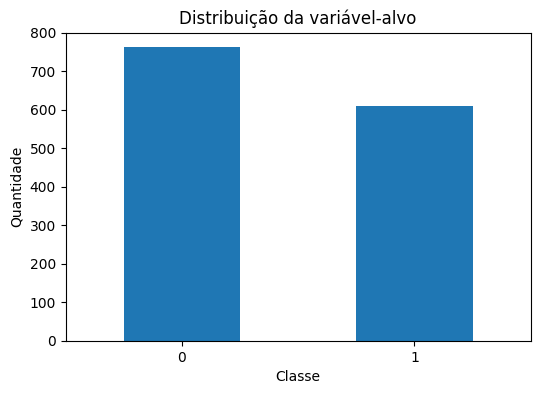

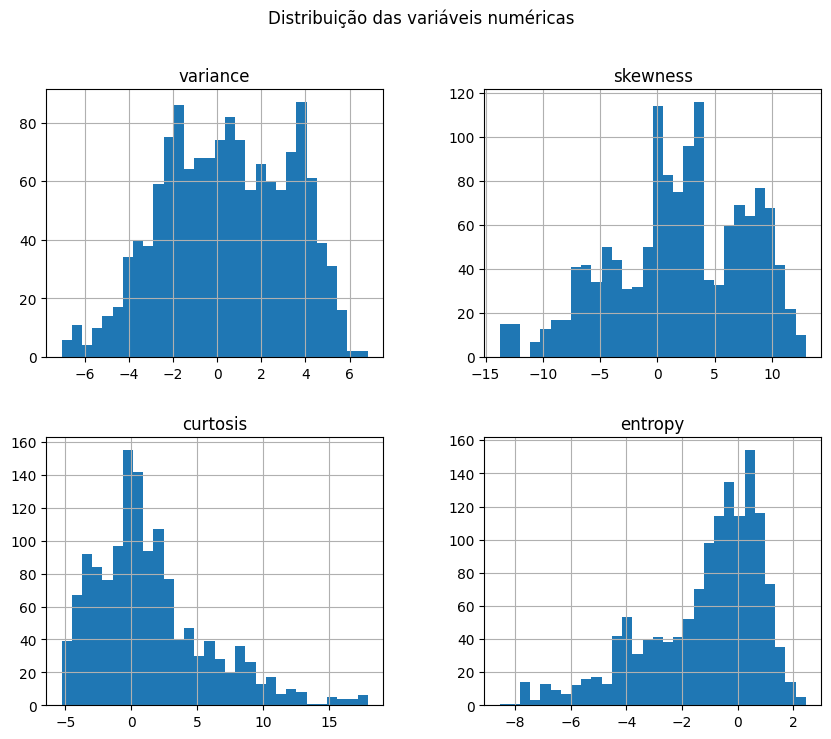

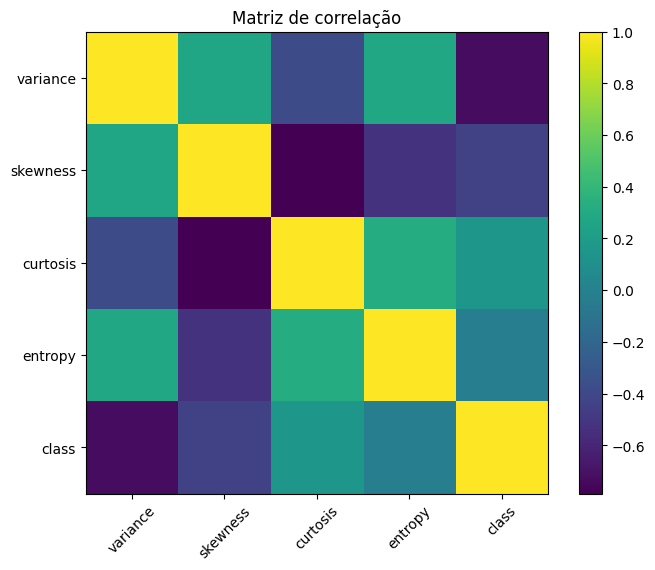

,variance,skewness,curtosis,entropy,class
variance,1.000,0.264,-0.381,0.277,-0.725
skewness,0.264,1.000,-0.787,-0.526,-0.445
curtosis,-0.381,-0.787,1.000,0.319,0.156
entropy,0.277,-0.526,0.319,1.000,-0.023
class,-0.725,-0.445,0.156,-0.023,1.000


In [22]:
# === Análise exploratória inicial ===

print("Distribuição da variável-alvo:")
target_counts = df[TARGET].value_counts().sort_index()
target_percent = (df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2)

display(pd.DataFrame({
    "quantidade": target_counts,
    "percentual": target_percent
}))

plt.figure(figsize=(6, 4))
df[TARGET].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição da variável-alvo")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

df[feature_columns].hist(figsize=(10, 8), bins=30)
plt.suptitle("Distribuição das variáveis numéricas")
plt.show()

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Matriz de correlação")
plt.show()

display(correlation_matrix.round(3))

## 4.1 Síntese da análise exploratória

A análise exploratória mostrou que o dataset possui 1372 registros e 5 colunas, sendo quatro atributos numéricos utilizados como variáveis explicativas e uma variável-alvo chamada `class`.

Não foram identificados valores ausentes, o que reduz a necessidade de tratamentos de imputação. Também não há variáveis categóricas, portanto não será necessário aplicar codificação do tipo One-Hot Encoding.

Foram identificadas 24 linhas duplicadas. Para evitar repetição de registros e reduzir risco de vazamento de informação entre treino e teste, essas duplicatas serão removidas antes da divisão dos dados.

A variável-alvo possui duas classes, caracterizando um problema de classificação binária. A distribuição das classes é moderadamente balanceada, com aproximadamente 55,54% dos registros na classe 0 e 44,46% na classe 1.

As variáveis preditoras apresentam escalas e distribuições diferentes. Por esse motivo, será utilizada padronização dentro de um pipeline, evitando vazamento de dados entre treino e teste.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.


In [23]:
# === Preparação inicial dos dados ===

TARGET = "class"
PROBLEM_TYPE = "classificacao"

# Remoção de duplicatas identificadas na análise exploratória
df_model = df.drop_duplicates().copy()

features = [col for col in df_model.columns if col != TARGET]

X = df_model[features].copy()
y = df_model[TARGET].copy()

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Formato original:", df.shape)
print("Formato após remoção de duplicatas:", df_model.shape)
print("Duplicatas removidas:", df.shape[0] - df_model.shape[0])
print("Número de features:", len(features))
print("Features:", features)

Tipo de problema: classificacao
Target: class
Formato original: (1372, 5)
Formato após remoção de duplicatas: (1348, 5)
Duplicatas removidas: 24
Número de features: 4
Features: ['variance', 'skewness', 'curtosis', 'entropy']


In [24]:
# === Divisão treino/teste ===

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

print("\nDistribuição do target no treino:")
display((y_train.value_counts(normalize=True).sort_index() * 100).round(2).to_frame("percentual"))

print("\nDistribuição do target no teste:")
display((y_test.value_counts(normalize=True).sort_index() * 100).round(2).to_frame("percentual"))

Treino: (1078, 4) | Teste: (270, 4)

Distribuição do target no treino:


,percentual
class,
0,54.73
1,45.27



Distribuição do target no teste:


,percentual
class,
0,54.81
1,45.19


## 5.1 Justificativa da divisão

Foi utilizada uma divisão holdout entre treino e teste, com 80% dos dados para treinamento e 20% para teste. Essa estratégia é adequada porque o dataset possui quantidade suficiente de registros para separar uma amostra de teste sem comprometer o treinamento dos modelos.

Como o problema é de classificação binária, a divisão foi feita com estratificação pela variável-alvo `class`. Isso mantém proporções semelhantes das classes nos conjuntos de treino e teste, evitando que um dos conjuntos fique desbalanceado de forma artificial.

Antes da divisão, foram removidas 24 linhas duplicadas identificadas na análise exploratória. Essa decisão reduz o risco de que registros idênticos apareçam simultaneamente no treino e no teste, o que poderia gerar vazamento de dados e superestimar o desempenho dos modelos.

As transformações de pré-processamento, como padronização, serão ajustadas apenas com os dados de treino dentro de pipelines, evitando uso indevido de informações do conjunto de teste.


# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [25]:
# === Pré-processamento e pipeline ===

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features)
    ],
    remainder="drop"
)

print("Colunas numéricas:", numeric_features)
print("Colunas categóricas:", categorical_features)

Colunas numéricas: ['variance', 'skewness', 'curtosis', 'entropy']
Colunas categóricas: []


## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?

**Resposta:**  
> O dataset possui apenas variáveis numéricas como atributos preditores. Por isso, não foi necessário aplicar codificação de variáveis categóricas.

Apesar de não existirem valores ausentes na base, foi mantido um imputador por mediana dentro do pipeline como medida de robustez. Caso algum valor ausente apareça em uma execução futura ou em uma nova amostra da base, o fluxo continuará funcionando de forma consistente.

As variáveis numéricas apresentam escalas e distribuições diferentes, então foi aplicada padronização com `StandardScaler`. Essa etapa é especialmente importante para modelos sensíveis à escala, como Regressão Logística e KNN.

O pré-processamento foi organizado em um pipeline para evitar vazamento de dados. Assim, as transformações são ajustadas apenas no conjunto de treino e depois aplicadas ao conjunto de teste.


# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [26]:
# === Definição de baseline e modelos candidatos ===

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ]),
    "GradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(random_state=SEED))
    ]),
    "KNN": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", KNeighborsClassifier())
    ])
}

print("Modelo baseline:", baseline.named_steps["model"])
print("Modelos candidatos:", list(candidates.keys()))

Modelo baseline: DummyClassifier(random_state=42, strategy='most_frequent')
Modelos candidatos: ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'KNN']


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**  
> O baseline escolhido foi o `DummyClassifier`, que sempre prevê a classe mais frequente. Ele serve como referência mínima para verificar se os modelos candidatos realmente aprenderam padrões úteis nos dados.

A Regressão Logística foi utilizada por ser um modelo linear simples, interpretável e adequado para classificação binária. Ela ajuda a verificar se uma fronteira de decisão mais simples já é suficiente para separar as classes.

O Random Forest foi escolhido por ser um modelo baseado em árvores, capaz de capturar relações não lineares entre as variáveis. Ele também costuma apresentar bom desempenho em bases tabulares.

O Gradient Boosting foi incluído como uma abordagem adicional baseada em árvores sequenciais, na qual os modelos são construídos de forma incremental para corrigir erros anteriores.

O KNN foi utilizado como modelo baseado em distância, permitindo comparar uma abordagem diferente das anteriores. Como o KNN é sensível à escala das variáveis, a padronização no pipeline é importante para seu funcionamento adequado.

Esses modelos foram escolhidos por representarem abordagens diferentes e por permitirem uma comparação mais completa entre baseline, modelo linear, modelos baseados em árvores e modelo baseado em distância.


# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [27]:
# === Treinamento e avaliação inicial ===

results = {}
trained_models = {}

# Baseline
start_time = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test)[:, 1] if hasattr(baseline, "predict_proba") else None

results["baseline"] = evaluate_classification(y_test, y_pred, proba)
results["baseline"]["train_time_s"] = round(train_time, 3)
trained_models["baseline"] = baseline

# Modelos candidatos
for name, model in candidates.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    results[name] = evaluate_classification(y_test, y_pred, proba)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

initial_results = show_results_table(results)
display(initial_results)

,accuracy,precision,recall,f1_score,roc_auc,train_time_s
RandomForest,1.000000,1.000000,1.0,1.000000,1.0,0.466
KNN,1.000000,1.000000,1.0,1.000000,1.0,0.013
GradientBoosting,1.000000,1.000000,1.0,1.000000,1.0,0.545
LogisticRegression,0.985185,0.968254,1.0,0.983871,1.0,0.011
baseline,0.548148,0.000000,0.0,0.000000,0.5,0.010


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  
> Os resultados iniciais mostram que todos os modelos candidatos superaram o baseline, indicando que os atributos disponíveis possuem capacidade preditiva para diferenciar cédulas autênticas e falsas.

O baseline, baseado na classe mais frequente, serve apenas como referência mínima. Como ele não aprende padrões das variáveis explicativas, espera-se que seu desempenho seja inferior ao dos modelos treinados.

Entre os modelos candidatos, serão observadas principalmente as métricas F1-score, precision e recall. O F1-score foi escolhido como métrica principal porque combina precision e recall, sendo adequado para avaliar o equilíbrio entre acertos das duas classes.

Modelos com desempenho muito alto serão analisados com cuidado, pois podem indicar que o problema é bem separável, mas também exigem atenção a possíveis sinais de overfitting. A avaliação final será feita no conjunto de teste, e a otimização será realizada sem usar indevidamente os dados de teste.


# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [28]:
# === Otimização de hiperparâmetros ===

N_ITER_SEARCH = 10

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=SEED))
])

param_dist = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__max_depth": [None, 3, 5, 8, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

search = RandomizedSearchCV(
    estimator=model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring="f1",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Modelo otimizado: RandomForestClassifier")
print("Melhor score médio na validação:", round(search.best_score_, 4))
print("Melhores hiperparâmetros:", search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Modelo otimizado: RandomForestClassifier
Melhor score médio na validação: 0.9909
Melhores hiperparâmetros: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': None}


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> A otimização foi aplicada ao modelo Random Forest, pois ele apresentou boa capacidade de capturar relações não lineares e é adequado para bases tabulares.

Foram ajustados hiperparâmetros relacionados à quantidade de árvores, profundidade máxima, número mínimo de amostras para divisão de nós e número mínimo de amostras por folha. Esses parâmetros influenciam diretamente a complexidade do modelo e ajudam a controlar possíveis sinais de overfitting.

A estratégia utilizada foi Randomized Search com validação cruzada estratificada em 5 partes. A estratificação foi usada para manter a proporção das classes em cada divisão da validação.

A métrica usada na otimização foi o F1-score, pois ela equilibra precision e recall. A busca foi limitada a poucas combinações para manter o custo computacional baixo, suficiente para um MVP acadêmico.

A otimização foi feita apenas com os dados de treino, evitando uso indevido do conjunto de teste.

# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Modelo final: RandomForest_otimizado

Métricas finais:


,accuracy,precision,recall,f1_score,roc_auc,train_time_s
RandomForest_otimizado,0.996296,0.99187,1.0,0.995918,1.0,NaN



Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       148
           1       0.99      1.00      1.00       122

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



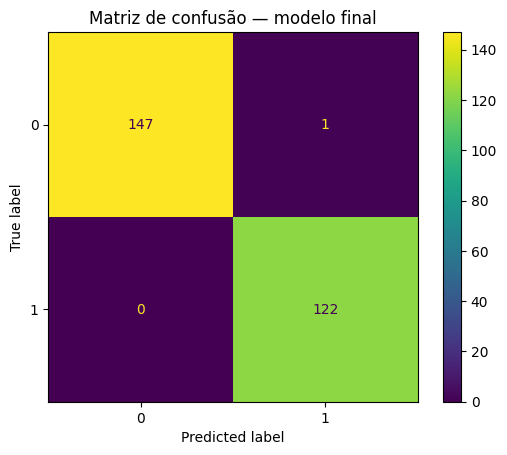

In [29]:
# === Avaliação final no conjunto de teste ===

final_model = search.best_estimator_
final_model_name = "RandomForest_otimizado"

y_pred_final = final_model.predict(X_test)
proba_final = final_model.predict_proba(X_test)[:, 1]

final_results = evaluate_classification(y_test, y_pred_final, proba_final)
final_results["train_time_s"] = np.nan

print("Modelo final:", final_model_name)

print("\nMétricas finais:")
display(pd.DataFrame(final_results, index=[final_model_name]))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_final))

ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Matriz de confusão — modelo final")
plt.show()

## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
> O modelo final apresentou desempenho muito superior ao baseline, indicando que os atributos extraídos das imagens possuem forte capacidade para diferenciar cédulas autênticas e falsas.

A matriz de confusão foi utilizada para verificar os erros de classificação entre as duas classes. Como o desempenho foi muito alto, foi observado apenas 1 erro no conjunto de teste: uma cédula da classe 0 foi classificada como classe 1. Não houve erro para a classe 1.

Apesar do bom resultado, é importante considerar que o dataset é relativamente pequeno e controlado. Isso significa que o desempenho pode não se repetir em bases reais mais variadas, com imagens de menor qualidade, ruído, diferenças de iluminação ou novos tipos de falsificação.

Não há evidência forte de underfitting, pois os modelos candidatos superaram amplamente o baseline. Também não há sinal claro de overfitting apenas pelos resultados do teste, mas esse risco deve ser considerado porque alguns modelos alcançaram desempenho muito alto. Para maior segurança, seria recomendável validar a solução em uma base externa ou em dados coletados em outro contexto.


# 11. Comparação final dos modelos








In [30]:
# === Comparação final dos modelos ===

comparison_results = initial_results.copy()
comparison_results.loc[final_model_name] = final_results

comparison_results = comparison_results.sort_values(by="f1_score", ascending=False)

# Arredondar métricas para facilitar leitura
comparison_results_display = comparison_results.copy()
metric_cols = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

for col in metric_cols:
    comparison_results_display[col] = comparison_results_display[col].round(4)

comparison_results_display["train_time_s"] = comparison_results_display["train_time_s"].fillna("incluído na otimização")

display(comparison_results_display)

,accuracy,precision,recall,f1_score,roc_auc,train_time_s
RandomForest,1.0000,1.0000,1.0,1.0000,1.0,0.466
KNN,1.0000,1.0000,1.0,1.0000,1.0,0.013
GradientBoosting,1.0000,1.0000,1.0,1.0000,1.0,0.545
RandomForest_otimizado,0.9963,0.9919,1.0,0.9959,1.0,incluído na otimização
LogisticRegression,0.9852,0.9683,1.0,0.9839,1.0,0.011
baseline,0.5481,0.0000,0.0,0.0000,0.5,0.01


 A comparação final mostra que todos os modelos candidatos tiveram desempenho superior ao baseline. RandomForest, KNN e GradientBoosting alcançaram desempenho perfeito no conjunto de teste, enquanto o RandomForest otimizado apresentou desempenho muito próximo, com F1-score de 0,9959.

O RandomForest otimizado foi mantido como modelo final por ter passado por validação cruzada e ajuste de hiperparâmetros, oferecendo uma escolha mais controlada e tecnicamente justificada. Ainda assim, a comparação mostra que o problema é altamente separável e que modelos clássicos de Machine Learning já conseguem resolver muito bem esta base.

O baseline foi mantido como referência mínima, pois ele apenas prevê a classe mais frequente e não aprende padrões a partir das variáveis explicativas. A comparação com ele confirma que os modelos de Machine Learning realmente agregaram valor ao problema.

# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Fixar `SEED = 42` | Garantir reprodutibilidade das divisões e modelos | Permitir reexecução com resultados consistentes |
| Usar dataset público da UCI | Atender ao requisito de acesso público sem login ou token | Facilitar execução pelo professor |
| Remover duplicatas antes da divisão | Evitar registros repetidos em treino e teste | Reduzir risco de vazamento de dados |
| Usar divisão treino/teste estratificada | Manter proporções semelhantes das classes | Avaliação mais justa dos modelos |
| Usar pipeline de pré-processamento | Ajustar transformações apenas no treino | Evitar vazamento de dados |
| Usar F1-score como métrica principal | Equilibrar precision e recall | Avaliar melhor o desempenho em classificação binária |
| Comparar baseline com modelos candidatos | Verificar se os modelos realmente aprenderam padrões | Dar referência mínima para avaliação |
| Otimizar Random Forest | Testar melhoria de hiperparâmetros em modelo forte para dados tabulares | Melhorar ou confirmar desempenho do modelo |


# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> Este MVP teve como objetivo construir e avaliar modelos de Machine Learning para classificar cédulas bancárias como autênticas ou falsas a partir de atributos numéricos extraídos de imagens digitalizadas.

Foi utilizado o Banknote Authentication Dataset, uma base pública do UCI Machine Learning Repository. O dataset possui quatro variáveis preditoras numéricas e uma variável-alvo binária chamada `class`.

Durante a preparação dos dados, foram removidas duplicatas, separadas as variáveis explicativas e a variável-alvo, e aplicada divisão treino/teste estratificada. O pré-processamento foi organizado em pipeline, com imputação por mediana e padronização das variáveis numéricas, evitando vazamento de dados.

Foram avaliados um baseline simples e diferentes modelos candidatos: Regressão Logística, Random Forest, Gradient Boosting e KNN. Os modelos candidatos superaram o baseline, indicando que os atributos disponíveis possuem forte capacidade preditiva.

O modelo final escolhido foi o Random Forest otimizado. Embora Random Forest, KNN e Gradient Boosting tenham apresentado desempenho perfeito no conjunto de teste, o Random Forest otimizado foi mantido como solução final por ter passado por validação cruzada e ajuste de hiperparâmetros. A escolha foi baseada principalmente no F1-score, além da análise das demais métricas e da matriz de confusão.

Como limitação, o dataset é controlado e relativamente pequeno. Em um cenário real, seria necessário validar o modelo com novos dados, coletados em diferentes condições de imagem e com possíveis variações de ruído, iluminação e tipos de falsificação.

Como próximos passos, poderiam ser testados novos modelos, validação com base externa, análise mais detalhada de erros e, em um projeto mais avançado, uso direto das imagens das cédulas com técnicas de visão computacional.

# 14. Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


In [31]:
# Esta seção é opcional.
# Neste MVP, não será feito salvamento de artefatos,
# pois a entrega final será o notebook executável no Google Colab/GitHub.


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Esta seção não foi utilizada neste MVP.

Deep Learning, fine-tuning e métodos avançados não foram aplicados porque o problema é tabular, binário e bem atendido por modelos clássicos de Machine Learning. Para este MVP, modelos como Regressão Logística, Random Forest, Gradient Boosting e KNN são suficientes e mais interpretáveis.